# CoLA Velocity Fields

In this notebook, we will be implementing a displacement gradient when a cortical laser ablation cut is made to a cell. This displacement field can then later be used to advect the actomyosin cortex.

In [1]:
import numpy as np

from IPython.display import HTML

Make sure to run `pip install -e .` before running the cell below. This command will make sure `diet4cola` is installed as a module in your current Python/Conda environment.

In [2]:
from diet4cola.generation.cola import CoLACut
from diet4cola.generation.operations import invert
from diet4cola.generation.velocity import prior_exponential, compute_velocity_field, compute_velocity_field_multi
from diet4cola.sdf import sdf_segment, sdf_box, compute_sdf, compute_rounded_sdf_multi

from diet4cola.utils import *

## Synthetic Actomyosin Cortex and CoLA Cut

As before, we start with creating a synthetic actomyosin cortex, followed by a CoLA cut.

In [3]:
# Cell parameters
seed = 42
width = 512
height = 512

np.random.seed(seed)
off_x = 256 + (np.random.randint(32) - 16)
off_y = 256 + (np.random.randint(32) - 16)

For now, we will simply load the example cortex obtained from a [previous notebook](./artificial_cola.ipynb).

In [4]:
actomyosin_layer = load_cortex('./data/cortex_1.npy')

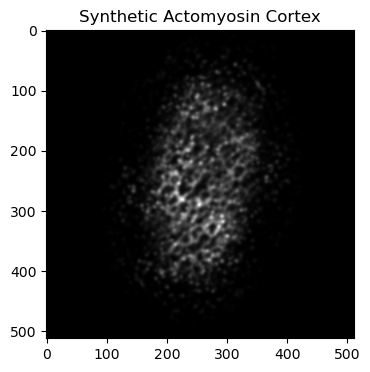

In [5]:
plot_2d_array(actomyosin_layer, 'Synthetic Actomyosin Cortex')

In [6]:
cola_cut = CoLACut((off_x, off_y), 32, 150, seed)

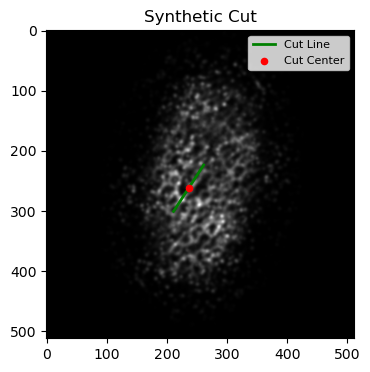

In [7]:
plot_synthetic_cut(actomyosin_layer, 
                   cola_cut.cut_center, 
                   cola_cut.cut_origin,
                   cola_cut.cut_destination)

## Velocity Model

The next important step is to decide how we are going to model the advection (i.e. how the cut evolves over time). From the provided original data, we have seen that the velocity is distinct in two ways:

- All points move away from the cut, following a specific distribution (expected to be exponential/hyperbolic)
- Points further away from the cut, will have an smaller initial velocity. The initial velocity decays exponentially with increasing distance to the cut.

A simple velocity model that captures these points is the following:

$$ \bold{v}_n(\bold{r}, t) = v(d, t)\bold{n}(\bold{r}, t) $$

where $\bold{r} = (x, y)$ the position of a point, $t$ represents the temporal dimension and $d$ is the distance to the cut boundary (represented by an SDF). Here we can choose different functions to model the initial velocity $v_0$ such as

- Exponential: $v(d, t) = v_0 e^{-dt/\lambda}$
- Hyperbolic: $v(d, t) = v_0 \frac{1}{1 + dt\lambda}$

where $\lambda$ the decay-length scale (i.e. how quickly velocity decreases with distance).

### Initial Velocity Field

Given some simple parameter choices, we can construct the velocity field based on the [Segment SDF](../diet4cola/sdf.py).

In [8]:
width, height = actomyosin_layer.shape
cut_sdf = compute_sdf(width, height, cola_cut.cut_origin, cola_cut.cut_destination, 0, True, sdf_segment)

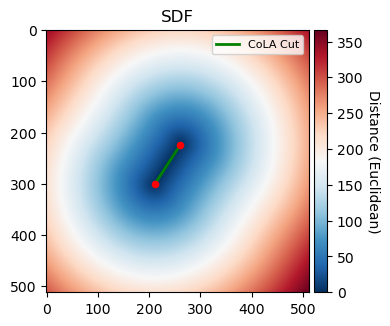

In [9]:
plot_sdf(cut_sdf, cola_cut.cut_origin, cola_cut.cut_destination, cmap='RdBu_r')

Let's use the `exponential` velocity prior:

$$ v(d, t) = v_0 \exp\!\left(-\frac{d t}{\lambda}\right) $$

More priors are available on [Desmos](https://www.desmos.com/calculator/ecfaltyqjn). Using this prior, we can easily create a velocity field.

In [10]:
velocity_prior = prior_exponential
velocity_field = compute_velocity_field(sdf=cut_sdf, velocity_prior=velocity_prior, t=1, v_0=1, k=30)

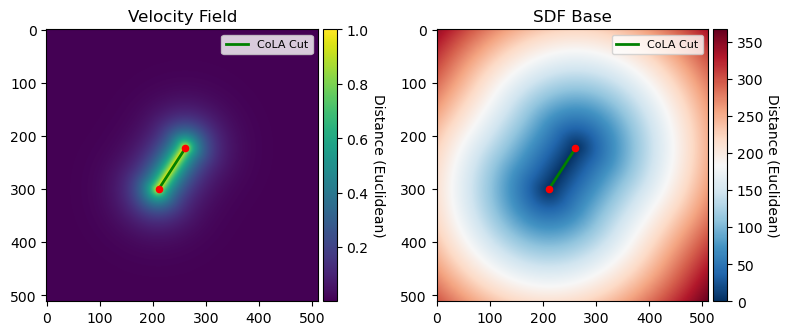

In [11]:
plot_velocity_field(velocity_field, cut_sdf, cola_cut.cut_origin, cola_cut.cut_destination)

### Parameter selection

We can generalize this. To do so, we will construct a velocity field w.r.t. a rounded box SDF that increases in width over time. The initial velocities at the boundary of the SDF (i.e. where it is 0) will be modeled by an exponential decay. Notice that the initial velocities are used **as an input** for the velocity prior `prior_exponential` per timepoint. This means that in general, the initial velocity decays exponentially near the boundary and the velocity everywhere else decays exponentially based on this.

In [12]:
t_min = 0
t_max = 10
iterations = 20

# From t_min, t_max, iterations, compute step
time_step = (t_max - t_min) / iterations

# Create time points
timepoints = np.arange(t_min, t_max, time_step)

Here we model the initial velocities over time. This means that, at $t=15$, the initial velocity at the boundary will be almost zero, meaning the cut doesn't expand anymore.

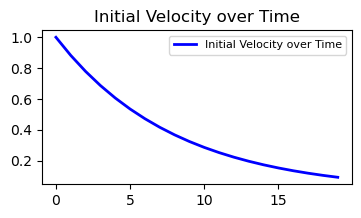

In [13]:
k = 0.25
initial_velocities = np.array([np.exp(-t * k) for t in timepoints])

plot_curve(initial_velocities, 'Initial Velocity over Time')

In [23]:
parameter = 25
radius = 25

In [24]:
parameters = np.array([parameter] * iterations)
radii = np.array([radius] * iterations)

Since **in this example** (does this truly hold?) we expect the boundary of the cut to exponentially slow down over time, we also expect the cut width to increase with an exponential decay. We can model this by simply inverting the initial velocities and inflating with a arbitrary value of our choosing.

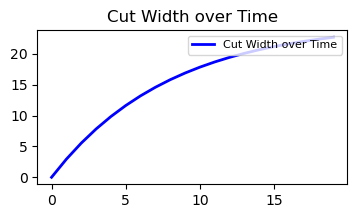

In [16]:
widths = invert(initial_velocities) * 25

plot_curve(widths, 'Cut Width over Time')

### SDF Generation

We can now generate the SDFs over time, representing the growing cut.

In [17]:
rounded_sdf_fields = compute_rounded_sdf_multi(512, 512, cola_cut.cut_origin, cola_cut.cut_destination, widths, radii, True, sdf_box, iterations)

100%|██████████| 20/20 [00:57<00:00,  2.85s/it]


Here we plot the initial state of the cut and the final state of the cut. This is based ONLY on the SDF. Next, we will use these SDFs over time to model the velocity fields.

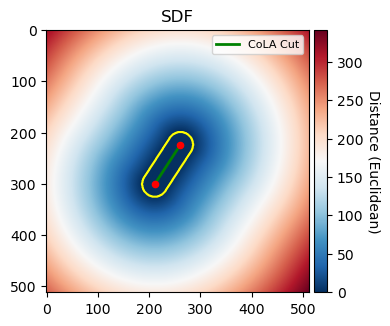

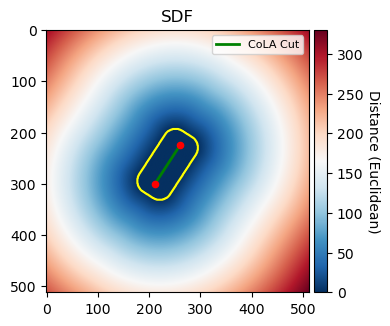

In [18]:
plot_sdf(rounded_sdf_fields[0], cola_cut.cut_origin, cola_cut.cut_destination)
plot_sdf(rounded_sdf_fields[-1], cola_cut.cut_origin, cola_cut.cut_destination)

### Velocity Field Generation

We can now generate the velocity fields based on the SDFs.

In [26]:
velocity_fields = compute_velocity_field_multi(rounded_sdf_fields, prior_exponential, timepoints, initial_velocities, parameters, iterations)

100%|██████████| 20/20 [00:03<00:00,  5.41it/s]


### SDF & Velocity Field Visualization

Here we visualize what we just created.

In [27]:
sdf_anim = animate_2d_data(rounded_sdf_fields, cola_cut.cut_origin, cola_cut.cut_destination, cmap='RdBu_r', title='SDF (Over Time)')
vel_anim = animate_2d_data(velocity_fields, cola_cut.cut_origin, cola_cut.cut_destination, cmap='viridis', title='Velocity (Over Time)')

In [28]:
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(sdf_anim.to_jshtml())
plt.close(sdf_anim._fig)  # <-- closes the figure so the static plot doesn't show
html_anim

In [29]:
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

html_anim = HTML(vel_anim.to_jshtml())
plt.close(vel_anim._fig)  # <-- closes the figure so the static plot doesn't show
html_anim